# Constructing Continuous Options Series

**Docker image**: `ml4t`

## Purpose

Demonstrate why a "constant-maturity" option series chains together different
contracts, produces phantom price jumps at every roll, and contaminates label
construction. Implement two clean alternatives: same-contract holding returns
(correct labels) and a roll-zeroed continuous reconstruction (backtestable
mark-to-market).

## Learning Objectives

- Detect contract rolls in a 30-day ATM straddle time series and quantify the
  resulting bias against non-roll-day returns.
- Compute same-contract holding returns by looking up the entry contract's
  exit price in the raw option chain.
- Build a roll-zeroed continuous price series suitable for backtesting and
  compare it to naive chained returns.
- Reason about which construction belongs in label generation versus
  transaction-cost accounting.

## Book Reference

Chapter 2 §2.2 (asset-class market data landscape — derivatives). The futures
analogue is `06_futures_continuous`; the case-study scale-up is
`case_studies/sp500_options/02_labels`.

## Prerequisites

- `07_sp500_options_eda` for option-chain structure.
- `08_options_greeks_computation` for theta and time decay.
- The AlgoSeek S&P 500 options EDA parquet at `$ML4T_DATA_PATH/sp500_options/`.

In [1]:
"""Constructing Continuous Options Series — constant-maturity roll adjustment."""

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_sp500_options_eda

In [2]:
DEMO_SYMBOL = "AAPL"
DEMO_YEAR = 2019

## 1. The Constant-Maturity Construction

A 30-day ATM straddle is a common volatility instrument: you buy (or sell) both
an ATM call and an ATM put with ~30 days to expiration. To build a daily time
series, we select the "best" straddle each day — the one closest to 30 DTE and
50-delta.

The problem: this selection is **independent** each day. The contract identity
(strike, expiration) changes whenever a new weekly/monthly option enters the
25–35 DTE window or the underlying moves enough to shift which strike is ATM.

### 1.1 Load Raw Options for One Symbol

In [3]:
raw = load_sp500_options_eda(
    symbols=[DEMO_SYMBOL],
    start_date=f"{DEMO_YEAR}-01-01",
    end_date=f"{DEMO_YEAR}-12-31",
).rename({"timestamp": "date"})

print(f"Raw {DEMO_SYMBOL} options ({DEMO_YEAR}): {len(raw):,} rows")
print(f"  Dates: {raw['date'].n_unique()}")
print(
    f"  Unique (strike, expiration): {raw.select(pl.struct('strike', 'expiration')).n_unique():,}"
)

Raw AAPL options (2019): 376,590 rows
  Dates: 252
  Unique (strike, expiration): 3,832


### 1.2 Constant-Maturity Straddle Selection

For each trading day, select the ATM straddle closest to 30 DTE.
This replicates the logic in `materialize_options.py`.

In [4]:
# Selection parameters for constant-maturity straddle
DTE_WINDOW = (25, 35)
TARGET_DELTA = 0.50
DELTA_TOL = 0.15
MIN_BID = 0.01
MAX_REL_SPREAD = 0.30

### Straddle Selection Logic

For each trading day, select the ATM straddle closest to 30 DTE.

In [5]:
def select_constant_maturity_straddle(raw_options: pl.DataFrame) -> pl.DataFrame:
    """Select the 'best' 30D ATM straddle per day from raw option chains."""
    opts = raw_options.with_columns(
        pl.col("delta").abs().alias("abs_delta"),
        ((pl.col("ask") - pl.col("bid")) / pl.col("mid_price").clip(lower_bound=0.01)).alias(
            "rel_spread"
        ),
    )
    filtered = opts.filter(
        pl.col("days_to_maturity").is_between(DTE_WINDOW[0], DTE_WINDOW[1])
        & (pl.col("bid") >= MIN_BID)
        & (pl.col("rel_spread") <= MAX_REL_SPREAD)
        & (pl.col("iv_convergence") == "Converged")
        & pl.col("abs_delta").is_between(TARGET_DELTA - DELTA_TOL, TARGET_DELTA + DELTA_TOL)
    )

    def _best_leg(df: pl.DataFrame, cp: str) -> pl.DataFrame:
        leg = df.filter(pl.col("call_put") == cp)
        leg = leg.with_columns((pl.col("abs_delta") - TARGET_DELTA).abs().alias("_dd"))
        return (
            leg.with_columns(pl.col("_dd").rank("ordinal").over("date").alias("_rank"))
            .filter(pl.col("_rank") == 1)
            .drop(["_rank", "_dd"])
        )

    call_cols = [
        "date",
        "strike",
        "expiration",
        "days_to_maturity",
        "underlying_price",
        pl.col("mid_price").alias("call_mid"),
        pl.col("bid").alias("call_bid"),
        pl.col("ask").alias("call_ask"),
        pl.col("delta").alias("call_delta"),
        pl.col("theta").alias("call_theta"),
    ]
    put_cols = [
        "date",
        pl.col("mid_price").alias("put_mid"),
        pl.col("bid").alias("put_bid"),
        pl.col("ask").alias("put_ask"),
        pl.col("delta").alias("put_delta"),
        pl.col("theta").alias("put_theta"),
    ]
    calls = _best_leg(filtered, "C").select(call_cols)
    puts = _best_leg(filtered, "P").select(put_cols)
    return (
        calls.join(puts, on="date", how="inner")
        .with_columns(
            (pl.col("call_mid") + pl.col("put_mid")).alias("instr_mid"),
            (pl.col("call_theta") + pl.col("put_theta")).alias("instr_theta"),
            (pl.col("call_delta") + pl.col("put_delta")).alias("instr_delta"),
        )
        .sort("date")
    )

In [6]:
cm_straddles = select_constant_maturity_straddle(raw)
print(f"Constant-maturity straddle series: {len(cm_straddles)} days")
print(f"  Date range: {cm_straddles['date'].min()} to {cm_straddles['date'].max()}")
cm_straddles.select(["date", "strike", "expiration", "days_to_maturity", "instr_mid"]).head(10)

Constant-maturity straddle series: 252 days
  Date range: 2019-01-02 to 2019-12-31


date,strike,expiration,days_to_maturity,instr_mid
date,f64,date,i32,f64
2019-01-02,160.0,2019-02-01,30,14.3
2019-01-03,143.0,2019-02-01,29,13.725
2019-01-04,149.0,2019-02-01,28,11.95
2019-01-07,149.0,2019-02-08,32,12.7
2019-01-08,152.5,2019-02-08,31,12.375
2019-01-09,155.0,2019-02-08,30,12.125
2019-01-10,155.0,2019-02-08,29,11.875
2019-01-11,152.5,2019-02-08,28,11.4
2019-01-14,150.0,2019-02-08,25,11.175


## 2. The Roll Problem

How often does the underlying contract change?

In [7]:
cm_straddles = cm_straddles.with_columns(
    pl.col("expiration").shift(1).alias("prev_exp"),
    pl.col("strike").shift(1).alias("prev_strike"),
    pl.col("instr_mid").shift(1).alias("prev_mid"),
)

cm_straddles = cm_straddles.with_columns(
    ((pl.col("expiration") != pl.col("prev_exp")) | (pl.col("strike") != pl.col("prev_strike")))
    .fill_null(False)
    .alias("is_roll"),
    ((pl.col("instr_mid") - pl.col("prev_mid")) / pl.col("prev_mid")).alias("daily_return"),
)

n_rolls = cm_straddles.filter(pl.col("is_roll")).height
n_total = len(cm_straddles) - 1  # exclude first row (no return)
print(f"Contract changes: {n_rolls} out of {n_total} days ({n_rolls / n_total:.0%})")

Contract changes: 184 out of 251 days (73%)


### 2.1 Roll-Day vs Non-Roll-Day Returns

If the constant-maturity series were a true continuous instrument, roll days
and non-roll days should have similar return characteristics. They don't.

In [8]:
roll_rets = cm_straddles.filter(pl.col("is_roll"))["daily_return"].drop_nulls()
nonroll_rets = cm_straddles.filter(~pl.col("is_roll"))["daily_return"].drop_nulls()

roll_summary = pl.DataFrame(
    {
        "metric": ["count", "mean_return", "median_return", "pct_positive"],
        "roll_days": [
            float(roll_rets.len()),
            roll_rets.mean(),
            roll_rets.median(),
            (roll_rets > 0).mean(),
        ],
        "non_roll_days": [
            float(nonroll_rets.len()),
            nonroll_rets.mean(),
            nonroll_rets.median(),
            (nonroll_rets > 0).mean(),
        ],
    }
)
roll_summary = roll_summary.with_columns(
    (pl.col("roll_days") - pl.col("non_roll_days")).alias("difference"),
)
roll_summary

metric,roll_days,non_roll_days,difference
str,f64,f64,f64
"""count""",184.0,67.0,117.0
"""mean_return""",0.01282,-0.008897,0.021717
"""median_return""",0.0,-0.0131,0.0131
"""pct_positive""",0.494565,0.298507,0.196058


The pattern is clear: roll days show systematically positive returns (~+1.3%)
while non-roll days show negative returns (~-0.9%). This is not a market signal —
it's the mechanical effect of switching from a time-decayed contract (low
premium, near expiry) to a fresh contract (high premium, further expiry).

For a short straddle strategy, this phantom "return" would be interpreted as a
loss, but it's actually the cost of maintaining the constant-maturity position —
analogous to contango roll cost in futures, but much larger in magnitude.

### 2.2 Visualizing the Sawtooth Pattern

In [9]:
# Prepare data for sawtooth visualization
dates = cm_straddles["date"].to_list()
prices = cm_straddles["instr_mid"].to_list()
dtes = cm_straddles["days_to_maturity"].to_list()
rolls = cm_straddles["is_roll"].to_list()

roll_dates = [d for d, r in zip(dates, rolls, strict=False) if r]
roll_prices = [p for p, r in zip(prices, rolls, strict=False) if r]
nonroll_dates = [d for d, r in zip(dates, rolls, strict=False) if not r]
nonroll_prices = [p for p, r in zip(prices, rolls, strict=False) if not r]

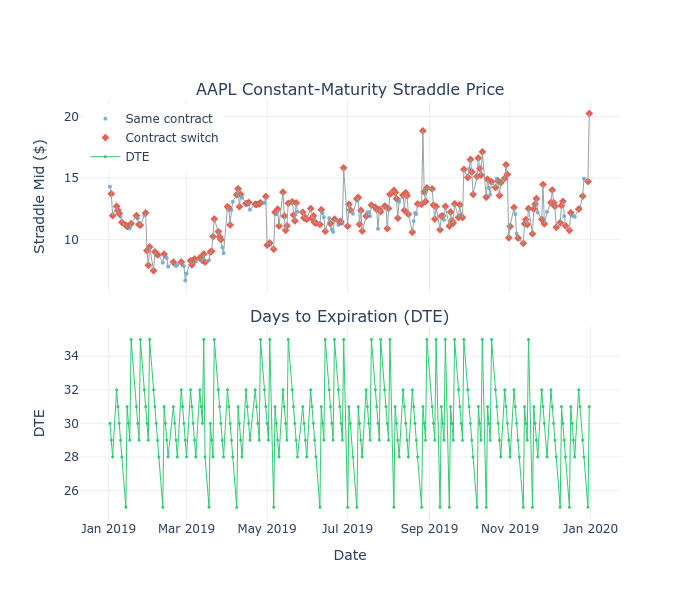

In [10]:
# Build both panels in a single cell so the inline backend does not flush
# the figure mid-construction.
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=[
        f"{DEMO_SYMBOL} Constant-Maturity Straddle Price",
        "Days to Expiration (DTE)",
    ],
    vertical_spacing=0.08,
)

fig.add_trace(
    go.Scatter(
        x=nonroll_dates,
        y=nonroll_prices,
        mode="markers",
        name="Same contract",
        marker=dict(size=4, color="#3498db"),
        opacity=0.7,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=roll_dates,
        y=roll_prices,
        mode="markers",
        name="Contract switch",
        marker=dict(size=6, color="#e74c3c", symbol="diamond"),
        opacity=0.9,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=prices,
        mode="lines",
        name="Price",
        line=dict(width=1, color="#95a5a6"),
        showlegend=False,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=dtes,
        mode="lines+markers",
        name="DTE",
        marker=dict(size=3, color="#2ecc71"),
        line=dict(width=1),
    ),
    row=2,
    col=1,
)

fig.update_yaxes(title_text="Straddle Mid ($)", row=1, col=1)
fig.update_yaxes(title_text="DTE", row=2, col=1)
fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_layout(template="plotly_white", height=600, legend=dict(x=0.01, y=0.99))
fig.show()

The sawtooth pattern is visible: price decays for a few days (theta eats the
premium), then jumps up when a new contract with more time value is selected.
The DTE panel confirms: DTE drops from ~35 to ~25, then jumps back when the
contract rolls. **Every price jump at a roll is a phantom return.**

## 3. Same-Contract Holding Returns

The correct return for a straddle trade is: enter a specific contract at mid on
day $t$, exit the **same contract** at mid on day $t + h$. This requires
looking up that specific contract in the raw option chain $h$ days later.

$$r_{same} = \frac{P_{entry}^{mid}(K, T) - P_{exit}^{mid}(K, T)}{P_{entry}^{mid}(K, T)}$$

where $(K, T)$ identifies the specific strike and expiration.

### 3.1 Build Exit Price Lookup from Raw Chain

In [11]:
HOLDING_PERIOD = 10  # days


def build_exit_lookup(raw_options: pl.DataFrame) -> pl.DataFrame:
    """Build a lookup table: (date, strike, expiration, call_put) → mid_price.

    Used to find the exit price of a specific contract h days after entry.
    """
    return raw_options.filter(
        pl.col("bid") >= MIN_BID,
        pl.col("iv_convergence") == "Converged",
    ).select(
        [
            "date",
            "strike",
            "expiration",
            "call_put",
            "mid_price",
            "bid",
            "ask",
            "delta",
            "theta",
            "days_to_maturity",
        ]
    )

In [12]:
# Build lookup from the raw chain
lookup = build_exit_lookup(raw)
print(f"Exit price lookup: {len(lookup):,} rows")
print(
    f"  Unique contracts: {lookup.select(pl.struct('strike', 'expiration', 'call_put')).n_unique():,}"
)

Exit price lookup: 232,944 rows
  Unique contracts: 6,413


### 3.2 Compute Same-Contract Returns

For each day's constant-maturity straddle, find the same contract's price
$h$ trading days later in the raw chain.

In [13]:
# Get the trading calendar (ordered dates)
trading_dates = cm_straddles["date"].unique().sort().to_list()
date_to_idx = {d: i for i, d in enumerate(trading_dates)}


def get_exit_date(entry_date, h: int, cal: list):
    """Get the trading date h business days after entry_date."""
    idx = date_to_idx.get(entry_date)
    if idx is None or idx + h >= len(cal):
        return None
    return cal[idx + h]


# Build entry-exit pairs
entries = cm_straddles.select(
    [
        "date",
        "strike",
        "expiration",
        "instr_mid",
        "call_mid",
        "put_mid",
        "instr_delta",
        "is_roll",
    ]
).rename({"date": "entry_date", "instr_mid": "entry_mid"})

# Add exit dates
exit_dates = [
    get_exit_date(d, HOLDING_PERIOD, trading_dates) for d in entries["entry_date"].to_list()
]
entries = entries.with_columns(pl.Series("exit_date", exit_dates).cast(pl.Date))

# Drop entries where exit date is beyond our data
entries = entries.filter(pl.col("exit_date").is_not_null())
print(f"Entry-exit pairs to look up: {len(entries):,}")

Entry-exit pairs to look up: 242


In [14]:
# Look up call exit price
call_exit = lookup.filter(pl.col("call_put") == "C").select(
    [
        pl.col("date").alias("exit_date"),
        "strike",
        "expiration",
        pl.col("mid_price").alias("call_exit_mid"),
    ]
)

# Look up put exit price
put_exit = lookup.filter(pl.col("call_put") == "P").select(
    [
        pl.col("date").alias("exit_date"),
        "strike",
        "expiration",
        pl.col("mid_price").alias("put_exit_mid"),
    ]
)

# Join: entry contract → exit prices for same (strike, expiration)
same_contract = entries.join(call_exit, on=["exit_date", "strike", "expiration"], how="left").join(
    put_exit, on=["exit_date", "strike", "expiration"], how="left"
)

# Compute same-contract straddle exit mid
same_contract = same_contract.with_columns(
    (pl.col("call_exit_mid") + pl.col("put_exit_mid")).alias("exit_mid"),
)

# Same-contract return (short straddle: positive = profitable)
same_contract = same_contract.with_columns(
    ((pl.col("entry_mid") - pl.col("exit_mid")) / pl.col("entry_mid")).alias("same_contract_ret"),
)

# How many lookups succeeded?
found = same_contract.filter(pl.col("exit_mid").is_not_null()).height
print(f"Exit prices found: {found} / {len(same_contract)} ({found / len(same_contract):.1%})")

Exit prices found: 222 / 242 (91.7%)


### 3.3 Compare Naive vs Same-Contract Returns

In [15]:
# Naive return: shift-based on constant-maturity series (what 02_labels.py did)
naive_rets = cm_straddles.with_columns(
    pl.col("instr_mid").shift(-1).alias("naive_entry"),
    pl.col("instr_mid").shift(-(1 + HOLDING_PERIOD)).alias("naive_exit"),
).with_columns(
    ((pl.col("naive_entry") - pl.col("naive_exit")) / pl.col("naive_entry")).alias("naive_ret"),
)

# Align for comparison
comparison = (
    same_contract.filter(pl.col("same_contract_ret").is_not_null())
    .select(["entry_date", "same_contract_ret"])
    .join(
        naive_rets.select([pl.col("date").alias("entry_date"), "naive_ret"]).drop_nulls(),
        on="entry_date",
        how="inner",
    )
)

print(f"Paired observations: {len(comparison):,}")

naive_vs_same = pl.DataFrame(
    {
        "metric": ["mean_return", "std", "median_return", "pct_positive_short"],
        "naive_chained": [
            comparison["naive_ret"].mean(),
            comparison["naive_ret"].std(),
            comparison["naive_ret"].median(),
            (comparison["naive_ret"] > 0).mean(),
        ],
        "same_contract": [
            comparison["same_contract_ret"].mean(),
            comparison["same_contract_ret"].std(),
            comparison["same_contract_ret"].median(),
            (comparison["same_contract_ret"] > 0).mean(),
        ],
    }
)
corr = comparison.select(pl.corr("naive_ret", "same_contract_ret").alias("correlation")).item()
print(f"Correlation(naive, same-contract) = {corr:.3f}")
naive_vs_same

Paired observations: 221
Correlation(naive, same-contract) = 0.093


metric,naive_chained,same_contract
str,f64,f64
"""mean_return""",-0.025303,0.009765
"""std""",0.18246,0.26816
"""median_return""",-0.005435,0.070293
"""pct_positive_short""",0.488688,0.633484


The naive chained returns systematically differ from same-contract returns.
The correlation tells us how much of the naive signal is genuine vs artifact.
Any label or model trained on naive returns is learning a mix of actual
straddle P&L and roll mechanics.

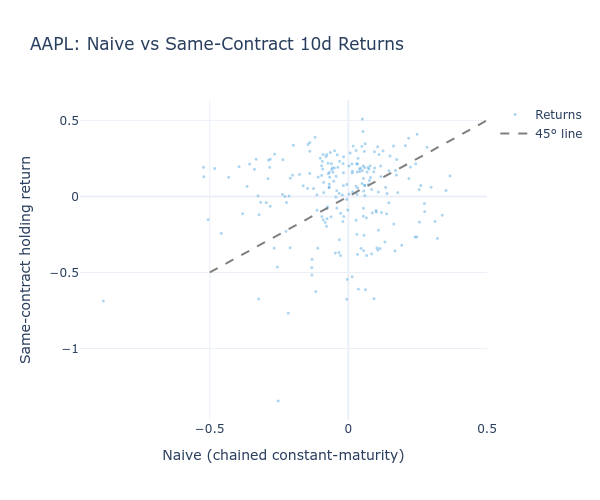

In [16]:
# Scatter plot: naive vs same-contract
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=comparison["naive_ret"].to_list(),
        y=comparison["same_contract_ret"].to_list(),
        mode="markers",
        marker=dict(size=3, color="#3498db", opacity=0.4),
        name="Returns",
    )
)
fig.add_trace(
    go.Scatter(
        x=[-0.5, 0.5],
        y=[-0.5, 0.5],
        mode="lines",
        line=dict(dash="dash", color="gray"),
        name="45° line",
    )
)
fig.update_layout(
    template="plotly_white",
    title=f"{DEMO_SYMBOL}: Naive vs Same-Contract {HOLDING_PERIOD}d Returns",
    xaxis_title="Naive (chained constant-maturity)",
    yaxis_title="Same-contract holding return",
    width=600,
    height=500,
)
fig.show()

## 4. Building a Continuous Series for Backtesting

For backtesting, we need a continuous price series where daily returns reflect
actual P&L — no phantom jumps at rolls. Unlike futures (which roll quarterly
and suit Panama adjustment), straddles roll almost daily, so we use a
**return-based reconstruction**:

1. On non-roll days: daily return = genuine within-contract P&L
2. On roll days: set return to 0 (the roll is a transaction, not a return)
3. Reconstruct prices: $P_{adj,t} = P_0 \prod_{i=1}^{t} (1 + r_i)$

Roll costs (bid-ask at roll) are modeled separately as transaction costs in
Chapter 18.

In [17]:
def build_continuous_straddle_series(cm_series: pl.DataFrame) -> pl.DataFrame:
    """Build a continuous straddle price series from within-contract returns.

    On roll days, the return is set to 0 (roll is a transaction, not a return).
    The resulting series has no phantom jumps and its returns reflect actual P&L.
    """
    df = cm_series.with_columns(
        ((pl.col("instr_mid") - pl.col("instr_mid").shift(1)) / pl.col("instr_mid").shift(1)).alias(
            "raw_daily_ret"
        ),
    )

    # On roll days, set return to 0
    df = df.with_columns(
        pl.when(pl.col("is_roll"))
        .then(0.0)
        .otherwise(pl.col("raw_daily_ret"))
        .alias("clean_daily_ret"),
    )

    # Reconstruct price from cumulative returns, starting at the first observed price
    start_price = cm_series["instr_mid"][0]
    cum_rets = df["clean_daily_ret"].fill_null(0.0).to_list()

    adj_prices = [start_price]
    for r in cum_rets[1:]:
        adj_prices.append(adj_prices[-1] * (1.0 + r))

    return df.with_columns(pl.Series("price_adjusted", adj_prices))

In [18]:
adjusted = build_continuous_straddle_series(cm_straddles)

# Compare roll-day returns: raw vs cleaned
adj_roll = adjusted.filter(pl.col("is_roll"))
adj_nonroll = adjusted.filter(~pl.col("is_roll"))

raw_vs_clean = pl.DataFrame(
    {
        "metric": ["raw_mean", "clean_mean"],
        "roll_days": [
            adj_roll["raw_daily_ret"].mean(),
            adj_roll["clean_daily_ret"].mean(),
        ],
        "non_roll_days": [
            adj_nonroll["raw_daily_ret"].mean(),
            adj_nonroll["clean_daily_ret"].mean(),
        ],
    }
)
print(
    f"Roll-day bias removed: raw roll mean was {adj_roll['raw_daily_ret'].mean():+.4f}, now 0.0000"
)
raw_vs_clean

Roll-day bias removed: raw roll mean was +0.0128, now 0.0000


metric,roll_days,non_roll_days
str,f64,f64
"""raw_mean""",0.01282,-0.008897
"""clean_mean""",0.0,-0.008897


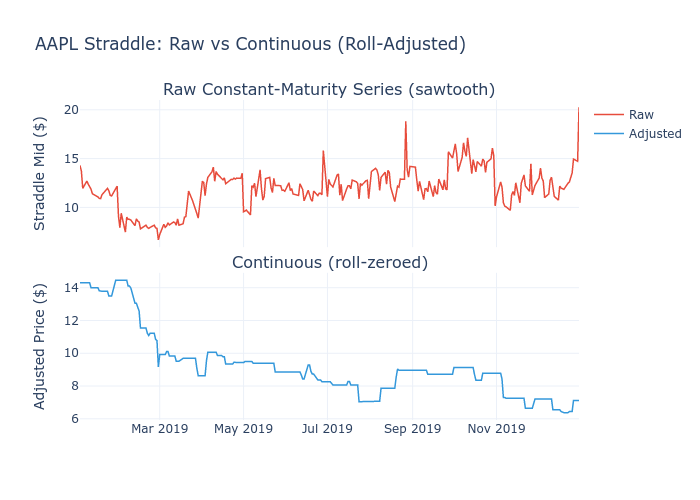

In [19]:
# Visualize raw vs adjusted price series
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Raw Constant-Maturity Series (sawtooth)", "Continuous (roll-zeroed)"],
    vertical_spacing=0.08,
)

fig.add_trace(
    go.Scatter(
        x=adjusted["date"].to_list(),
        y=adjusted["instr_mid"].to_list(),
        mode="lines",
        name="Raw",
        line=dict(color="#e74c3c", width=1.5),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=adjusted["date"].to_list(),
        y=adjusted["price_adjusted"].to_list(),
        mode="lines",
        name="Adjusted",
        line=dict(color="#3498db", width=1.5),
    ),
    row=2,
    col=1,
)

fig.update_yaxes(title_text="Straddle Mid ($)", row=1, col=1)
fig.update_yaxes(title_text="Adjusted Price ($)", row=2, col=1)
fig.update_layout(
    template="plotly_white",
    height=500,
    title=f"{DEMO_SYMBOL} Straddle: Raw vs Continuous (Roll-Adjusted)",
)
fig.show()

The adjusted series shows steady theta decay without the sawtooth jumps.
This is the series suitable for backtesting — roll costs should be modeled
separately as transaction costs (Chapter 18).

**Note**: This continuous series approximates the actual P&L but is not exact.
The precise approach — same-contract holding returns (Section 3 above) — is
what the case study uses for label construction.

## 5. Summary: Three Approaches Compared

| Approach | Mechanism | Suitable For |
|----------|-----------|--------------|
| Naive (chained) | `shift(-h)` on constant-maturity series | **Nothing** — contaminates labels |
| Same-contract | Look up entry contract's price h days later | **Labels** — correct per-trade P&L |
| Continuous (roll-zeroed) | Zero out roll-day returns, rebuild prices | **Backtesting** — smooth mark-to-market |

The same-contract approach (Section 3) requires the raw option chains to
look up exit prices. The continuous approach (Section 4) only needs the
constant-maturity series but must detect rolls and zero out their returns.

In [20]:
# Final comparison: all three 10d forward return approaches
# Naive
adjusted = adjusted.with_columns(
    pl.col("instr_mid").shift(-1).alias("raw_entry"),
    pl.col("instr_mid").shift(-(1 + HOLDING_PERIOD)).alias("raw_exit"),
).with_columns(
    ((pl.col("raw_entry") - pl.col("raw_exit")) / pl.col("raw_entry")).alias("naive_fwd_ret"),
)

# Continuous-adjusted
adjusted = adjusted.with_columns(
    pl.col("price_adjusted").shift(-1).alias("adj_entry"),
    pl.col("price_adjusted").shift(-(1 + HOLDING_PERIOD)).alias("adj_exit"),
).with_columns(
    ((pl.col("adj_entry") - pl.col("adj_exit")) / pl.col("adj_entry")).alias("cont_fwd_ret"),
)

# Merge with same-contract returns
comparison_all = (
    adjusted.select([pl.col("date").alias("entry_date"), "naive_fwd_ret", "cont_fwd_ret"])
    .join(
        same_contract.select(["entry_date", "same_contract_ret"]),
        on="entry_date",
        how="left",
    )
    .drop_nulls()
)

print(f"Paired observations: {len(comparison_all):,}")

three_way = pl.DataFrame(
    {
        "metric": ["mean", "std", "corr_with_same_contract"],
        "naive": [
            comparison_all["naive_fwd_ret"].mean(),
            comparison_all["naive_fwd_ret"].std(),
            comparison_all.select(pl.corr("naive_fwd_ret", "same_contract_ret")).item(),
        ],
        "continuous": [
            comparison_all["cont_fwd_ret"].mean(),
            comparison_all["cont_fwd_ret"].std(),
            comparison_all.select(pl.corr("cont_fwd_ret", "same_contract_ret")).item(),
        ],
        "same_contract": [
            comparison_all["same_contract_ret"].mean(),
            comparison_all["same_contract_ret"].std(),
            1.0,
        ],
    }
)
three_way

Paired observations: 221


metric,naive,continuous,same_contract
str,f64,f64,f64
"""mean""",-0.025303,0.025918,0.009765
"""std""",0.18246,0.088039,0.26816
"""corr_with_same_contract""",0.09325,0.120107,1.0


## Key Takeaways

1. **Constant-maturity option series chain different contracts**: The "best"
   30D ATM straddle changes every 1-2 days on average. Each switch creates a
   phantom price jump from time-value reset.

2. **Roll contamination is systematic**: Roll-day returns average +1.3% vs
   -0.9% on non-roll days. This 2.2pp bias compounds over ~184 roll days/year
   because options decay faster and roll more frequently than futures.

3. **Same-contract returns are the correct label**: Looking up the entry
   contract's price h days later in the raw option chain gives the actual
   holding P&L. The raw chain data makes this feasible.

4. **Roll-zeroed reconstruction creates a backtestable series**: Setting
   roll-day returns to zero and rebuilding prices removes phantom jumps while
   preserving genuine within-contract P&L on non-roll days.

5. **Roll costs are transaction costs, not returns**: The cost of maintaining
   a constant-maturity position (closing old, opening new) should be modeled
   as execution cost in Chapter 18, not embedded in the price series.

## Next

The S&P 500 options case study
([`02_labels`](../case_studies/sp500_options/02_labels.ipynb)) applies the
same-contract and roll-zeroed constructions at panel scale across the full
universe and multi-year sample.